<a href="https://colab.research.google.com/github/AROO-6/Codesoft-Task/blob/main/SMS_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk scikit-learn pandas matplotlib seaborn wordcloud xgboost --quiet
print("All packages ready!")

All packages ready!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from collections   import Counter

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Classifiers
from sklearn.naive_bayes     import MultinomialNB, ComplementNB
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC, SVC
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from xgboost                 import XGBClassifier

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline      import Pipeline

# Visuals
from wordcloud import WordCloud
import joblib

# Download NLTK data
for pkg in ['stopwords', 'wordnet', 'punkt', 'omw-1.4', 'averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
print("All imports successful!")

All imports successful!


In [ ]:
# Download the SMS Spam dataset from UCI repository
!wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip" -O sms_spam.zip
!unzip -q sms_spam.zip

# Load it — tab-separated, no header
df = pd.read_csv('SMSSpamCollection', sep='\t', header=None,
                 names=['label', 'message'], encoding='latin-1')

print(f"Dataset loaded: {len(df):,} messages")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
df.head(10)

Dataset loaded: 5,572 messages

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [ ]:
# Quick sanity check
print("Dataset info:")
print(f"  Total messages : {len(df):,}")
print(f"  Spam messages  : {sum(df['label']=='spam'):,}  ({sum(df['label']=='spam')/len(df)*100:.1f}%)")
print(f"  Ham messages   : {sum(df['label']=='ham'):,}  ({sum(df['label']=='ham')/len(df)*100:.1f}%)")
print(f"  Missing values : {df.isnull().sum().sum()}")
print(f"  Duplicate rows : {df.duplicated().sum()}")

# Drop duplicates if any
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nAfter removing duplicates: {len(df):,} messages")

Dataset info:
  Total messages : 5,572
  Spam messages  : 747  (13.4%)
  Ham messages   : 4,825  (86.6%)
  Missing values : 0
  Duplicate rows : 403

After removing duplicates: 5,169 messages


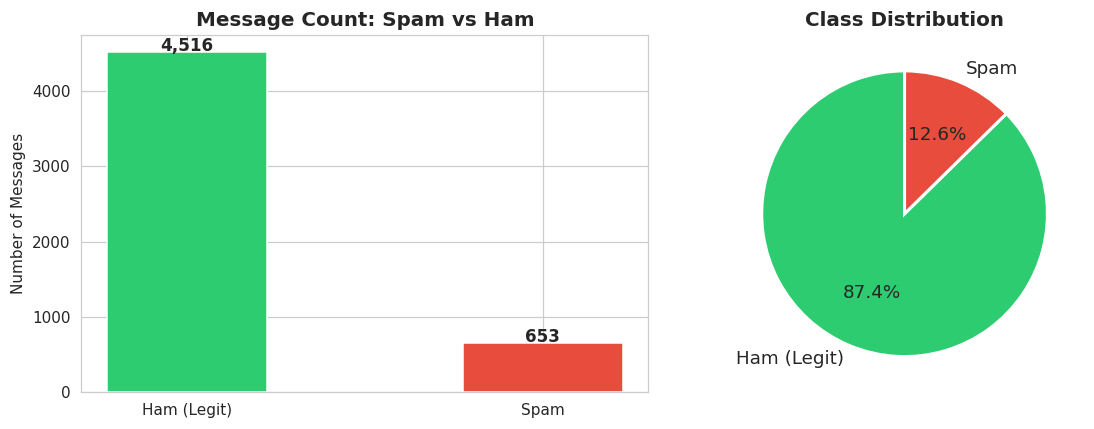

In [ ]:
# Overall class distribution
label_counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Ham (Legit)', 'Spam'], label_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.45)
axes[0].set_title('Message Count: Spam vs Ham', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Messages')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

axes[1].pie(label_counts.values, labels=['Ham (Legit)', 'Spam'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Class Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Add some basic text features — length, word count, special characters
df['message_length']  = df['message'].apply(len)
df['word_count']      = df['message'].apply(lambda x: len(x.split()))
df['num_digits']      = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['num_uppercase']   = df['message'].apply(lambda x: sum(c.isupper() for c in x))
df['num_punctuation'] = df['message'].apply(lambda x: sum(c in string.punctuation for c in x))
df['has_link']        = df['message'].apply(
    lambda x: int(bool(re.search(r'http|www|bit\.ly|tinyurl', x, re.IGNORECASE)))
)
df['has_phone']       = df['message'].apply(
    lambda x: int(bool(re.search(r'\b\d{10,}\b|\b\d{3}[-.]\d{4}\b', x)))
)
df['has_free']        = df['message'].apply(
    lambda x: int(bool(re.search(r'\bfree\b|\bwon\b|\bwinner\b|\bclaim\b|\bprize\b', x, re.IGNORECASE)))
)

print("Extra features added:")
print(df[['label','message_length','word_count','num_digits',
          'num_uppercase','has_link','has_free']].groupby('label').mean().round(2))

Extra features added:
       message_length  word_count  num_digits  num_uppercase  has_link  \
label                                                                    
ham             70.99       14.24        0.30           4.02      0.00   
spam           138.13       23.74       15.49          15.68      0.14   

       has_free  
label            
ham        0.02  
spam       0.42  


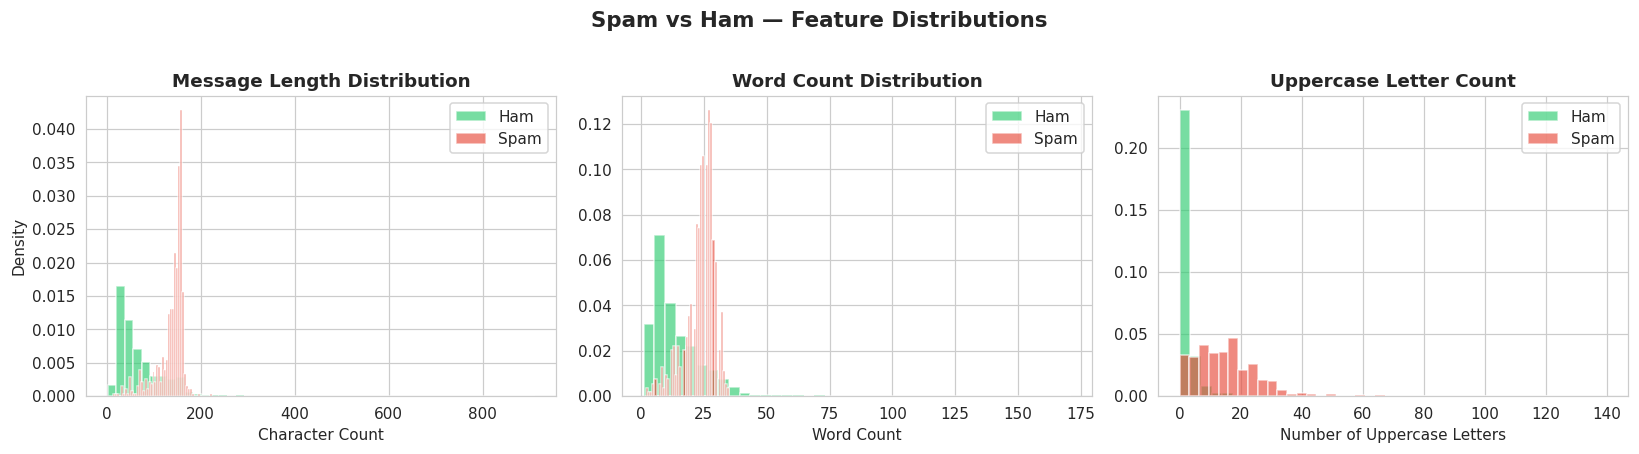

Key pattern:
  Avg spam length : 138 chars
  Avg ham  length : 71 chars
  Spam messages tend to be longer and use more uppercase letters!


In [ ]:
# Compare message length and word count between spam and ham
spam_msgs = df[df['label'] == 'spam']
ham_msgs  = df[df['label'] == 'ham']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Message length
axes[0].hist(ham_msgs['message_length'],  bins=50, alpha=0.65,
             color='#2ecc71', label='Ham',  density=True)
axes[0].hist(spam_msgs['message_length'], bins=50, alpha=0.65,
             color='#e74c3c', label='Spam', density=True)
axes[0].set_title('Message Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Density')
axes[0].legend()

# Word count
axes[1].hist(ham_msgs['word_count'],  bins=40, alpha=0.65,
             color='#2ecc71', label='Ham',  density=True)
axes[1].hist(spam_msgs['word_count'], bins=40, alpha=0.65,
             color='#e74c3c', label='Spam', density=True)
axes[1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()

# Uppercase characters
axes[2].hist(ham_msgs['num_uppercase'],  bins=40, alpha=0.65,
             color='#2ecc71', label='Ham',  density=True)
axes[2].hist(spam_msgs['num_uppercase'], bins=40, alpha=0.65,
             color='#e74c3c', label='Spam', density=True)
axes[2].set_title('Uppercase Letter Count', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Uppercase Letters')
axes[2].legend()

plt.suptitle('Spam vs Ham — Feature Distributions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key pattern:")
print(f"  Avg spam length : {spam_msgs['message_length'].mean():.0f} chars")
print(f"  Avg ham  length : {ham_msgs['message_length'].mean():.0f} chars")
print(f"  Spam messages tend to be longer and use more uppercase letters!")

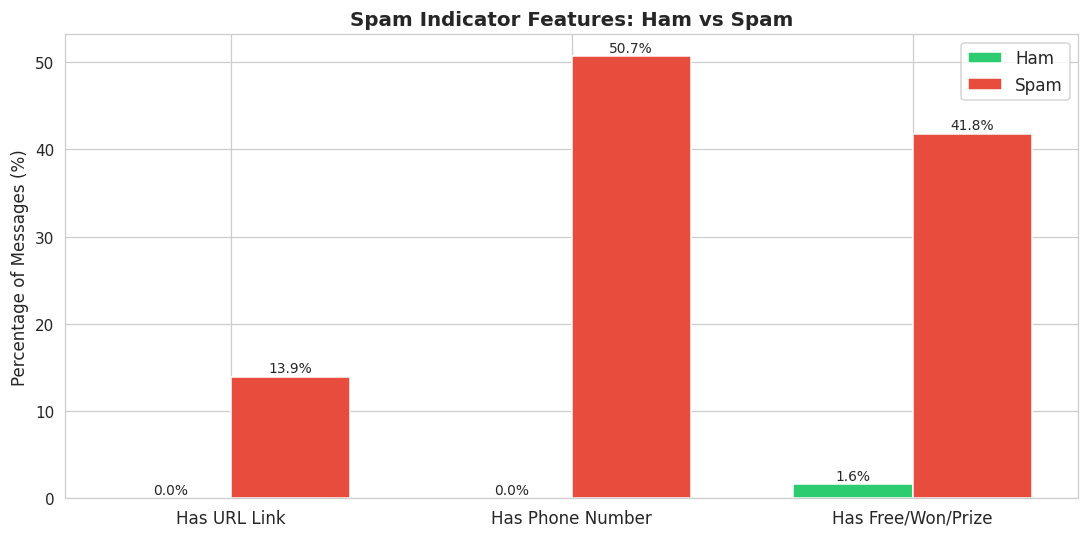

In [ ]:
# Spam indicator features comparison
indicator_cols = ['has_link', 'has_phone', 'has_free']
indicator_labels = ['Has URL Link', 'Has Phone Number', 'Has Free/Won/Prize']

spam_rates = [spam_msgs[col].mean() * 100 for col in indicator_cols]
ham_rates  = [ham_msgs[col].mean()  * 100 for col in indicator_cols]

x = np.arange(len(indicator_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, ham_rates,  width, label='Ham',  color='#2ecc71', edgecolor='white')
b2 = ax.bar(x + width/2, spam_rates, width, label='Spam', color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(indicator_labels, fontsize=11)
ax.set_ylabel('Percentage of Messages (%)', fontsize=11)
ax.set_title('Spam Indicator Features: Ham vs Spam', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

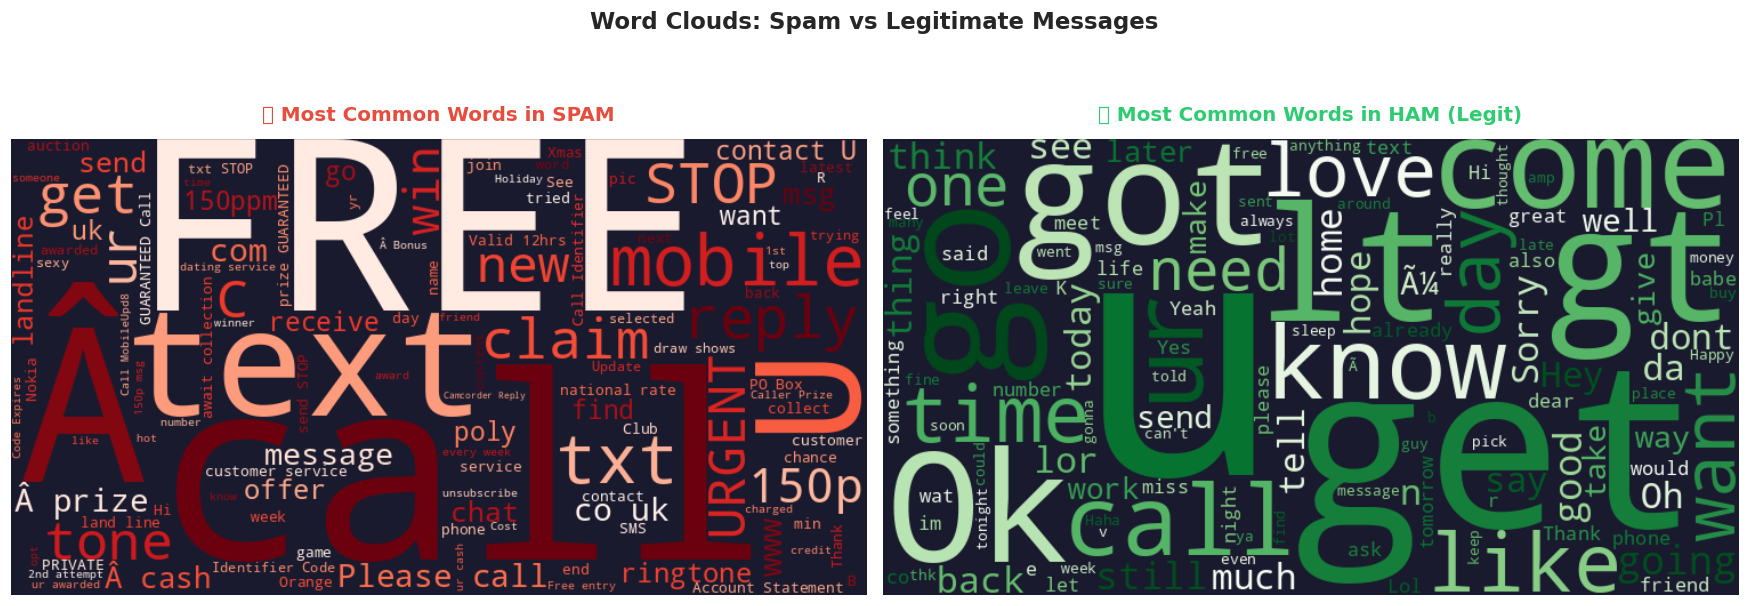

In [ ]:
# Word clouds — most common words in spam vs ham
spam_text = ' '.join(spam_msgs['message'].values)
ham_text  = ' '.join(ham_msgs['message'].values)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_spam = WordCloud(width=750, height=400, background_color='#1a1a2e',
                    colormap='Reds', max_words=120,
                    stopwords=set(stopwords.words('english')))
wc_spam.generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('🚫 Most Common Words in SPAM',
                   fontsize=13, fontweight='bold', pad=12, color='#e74c3c')

wc_ham = WordCloud(width=750, height=400, background_color='#1a1a2e',
                   colormap='Greens', max_words=120,
                   stopwords=set(stopwords.words('english')))
wc_ham.generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('✅ Most Common Words in HAM (Legit)',
                   fontsize=13, fontweight='bold', pad=12, color='#2ecc71')

plt.suptitle('Word Clouds: Spam vs Legitimate Messages',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

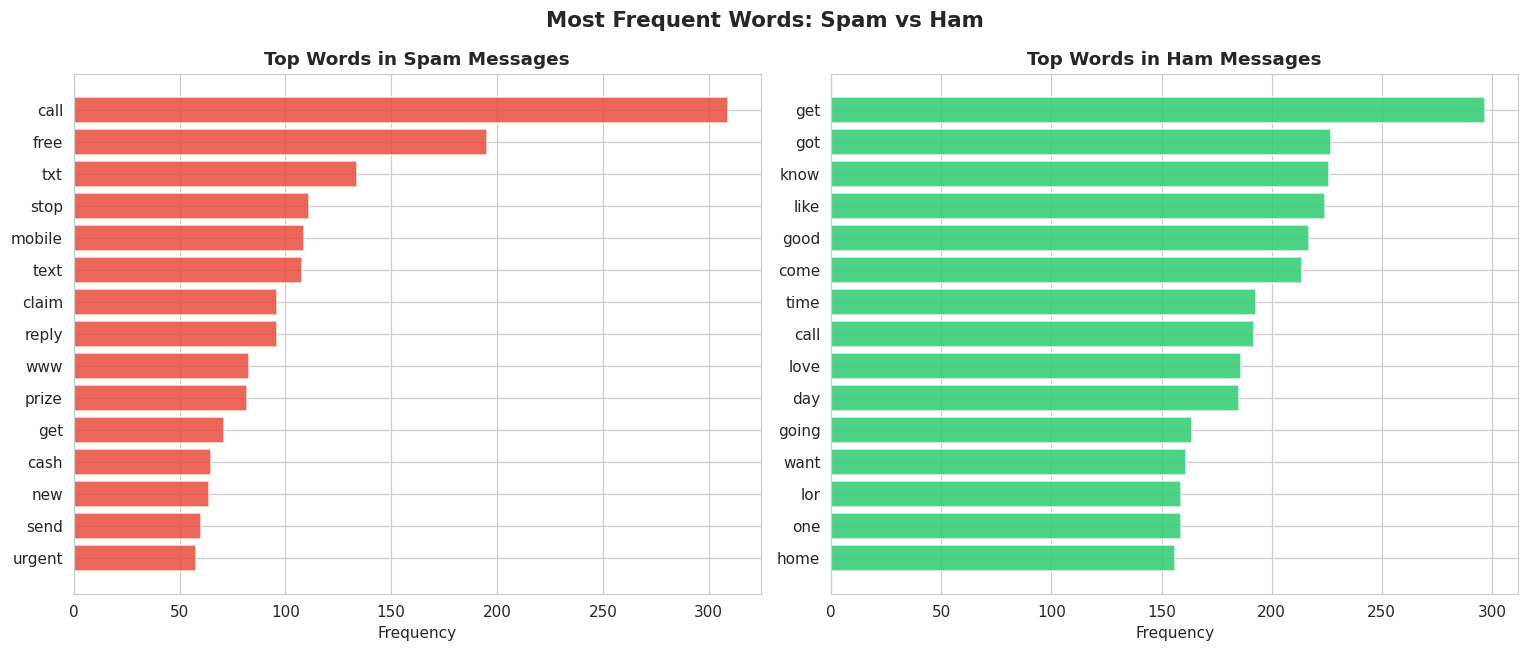

In [ ]:
# Top 15 most frequent words in spam and ham (excluding stopwords)
stop_words = set(stopwords.words('english'))

def get_top_words(text_series, n=15):
    all_words = []
    for msg in text_series:
        words = re.findall(r'\b[a-z]{3,}\b', msg.lower())
        all_words.extend([w for w in words if w not in stop_words])
    return Counter(all_words).most_common(n)

top_spam = get_top_words(spam_msgs['message'])
top_ham  = get_top_words(ham_msgs['message'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

spam_words, spam_counts = zip(*top_spam)
axes[0].barh(range(len(spam_words)), spam_counts[::-1],
             color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(len(spam_words)))
axes[0].set_yticklabels(spam_words[::-1], fontsize=10)
axes[0].set_title('Top Words in Spam Messages', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')

ham_words, ham_counts = zip(*top_ham)
axes[1].barh(range(len(ham_words)), ham_counts[::-1],
             color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(ham_words)))
axes[1].set_yticklabels(ham_words[::-1], fontsize=10)
axes[1].set_title('Top Words in Ham Messages', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Most Frequent Words: Spam vs Ham', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

# We keep a few spam-signal words that are normally stopwords
keep_words = {'free', 'win', 'won', 'prize', 'cash', 'call', 'now', 'urgent', 'claim'}
stop_words = stop_words - keep_words


def preprocess(text, use_stemming=False):
    """Full text cleaning pipeline."""

    # Lowercase
    text = text.lower()

    # Replace common abbreviations / slang
    text = re.sub(r'\bu r\b',  'you are',   text)
    text = re.sub(r'\bur\b',   'your',      text)
    text = re.sub(r'\bm8\b',   'mate',      text)
    text = re.sub(r'\b2day\b', 'today',     text)
    text = re.sub(r'\bgr8\b',  'great',     text)

    # Replace URLs with token
    text = re.sub(r'http\S+|www\.\S+|bit\.ly\S+', ' urltoken ', text)

    # Replace phone numbers with token
    text = re.sub(r'\b\d{10,}\b|\b\d{3}[-.\s]\d{3}[-.\s]\d{4}\b', ' phonetoken ', text)

    # Replace currency symbols
    text = re.sub(r'[£$€]', ' moneytoken ', text)

    # Remove remaining punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    if use_stemming:
        tokens = [stemmer.lemmatize(t) for t in tokens
                  if t not in stop_words and len(t) > 1]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens
                  if t not in stop_words and len(t) > 1]

    return ' '.join(tokens)


print("Preprocessing all messages...")
df['clean_message'] = df['message'].apply(preprocess)
print("Done!")

# Show a before/after example for spam and ham
print("\n" + "="*60)
print("SPAM example:")
idx = spam_msgs.index[0]
print(f"  Before: {df.loc[idx,'message']}")
print(f"  After : {df.loc[idx,'clean_message']}")

print("\nHAM example:")
idx2 = ham_msgs.index[0]
print(f"  Before: {df.loc[idx2,'message']}")
print(f"  After : {df.loc[idx2,'clean_message']}")

Preprocessing all messages...
Done!

SPAM example:
  Before: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  After : free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate apply

HAM example:
  Before: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  After : go jurong point crazy available bugis great world la buffet cine got amore wat


In [ ]:
# Encode label: spam = 1, ham = 0
df['label_encoded'] = (df['label'] == 'spam').astype(int)

X_text = df['clean_message']
y      = df['label_encoded']

# Stratified split — keeps spam ratio consistent
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training messages : {len(X_train_text):,}")
print(f"Test messages     : {len(X_test_text):,}")
print(f"Spam in train     : {y_train.mean()*100:.1f}%")
print(f"Spam in test      : {y_test.mean()*100:.1f}%")

Training messages : 4,135
Test messages     : 1,034
Spam in train     : 12.6%
Spam in test      : 12.7%


In [ ]:
# TF-IDF Vectorizer — unigrams + bigrams for richer features
# We include character n-grams too (analyzer='char_wb') — great for catching spam tricks

tfidf_word = TfidfVectorizer(
    analyzer   = 'word',
    ngram_range = (1, 2),     # unigrams and bigrams
    max_features = 15000,
    min_df      = 2,          # ignore very rare terms
    sublinear_tf = True,      # log scaling
    strip_accents = 'unicode'
)

tfidf_char = TfidfVectorizer(
    analyzer    = 'char_wb',
    ngram_range = (3, 5),     # character 3-grams to 5-grams
    max_features = 10000,
    min_df      = 3,
    sublinear_tf = True
)

# Fit on training data only!
X_train_word = tfidf_word.fit_transform(X_train_text)
X_test_word  = tfidf_word.transform(X_test_text)

X_train_char = tfidf_char.fit_transform(X_train_text)
X_test_char  = tfidf_char.transform(X_test_text)

print(f"Word TF-IDF shape : {X_train_word.shape}")
print(f"Char TF-IDF shape : {X_train_char.shape}")

Word TF-IDF shape : (4135, 5667)
Char TF-IDF shape : (4135, 10000)


In [ ]:
# Combine word TF-IDF + char TF-IDF + hand-crafted features
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

hand_crafted_cols = [
    'message_length', 'word_count', 'num_digits',
    'num_uppercase', 'num_punctuation',
    'has_link', 'has_phone', 'has_free'
]

# Get train/test indices from the split
train_idx = X_train_text.index
test_idx  = X_test_text.index

scaler_hc = StandardScaler()
X_train_hc = scaler_hc.fit_transform(df.loc[train_idx, hand_crafted_cols])
X_test_hc  = scaler_hc.transform(df.loc[test_idx,  hand_crafted_cols])

# Combine everything into one big feature matrix
X_train_combined = hstack([X_train_word, X_train_char, csr_matrix(X_train_hc)])
X_test_combined  = hstack([X_test_word,  X_test_char,  csr_matrix(X_test_hc)])

print(f"Combined feature matrix shape: {X_train_combined.shape}")
print(f"  Word TF-IDF : {X_train_word.shape[1]:,} features")
print(f"  Char TF-IDF : {X_train_char.shape[1]:,} features")
print(f"  Hand-crafted: {len(hand_crafted_cols)} features")

Combined feature matrix shape: (4135, 15675)
  Word TF-IDF : 5,667 features
  Char TF-IDF : 10,000 features
  Hand-crafted: 8 features


In [ ]:
classifiers = {
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Complement NB':       ComplementNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(
                               C=5.0, max_iter=1000,
                               solver='lbfgs', random_state=42
                           ),
    'Linear SVM':          LinearSVC(
                               C=1.0, max_iter=2000, random_state=42
                           ),
    'Random Forest':       RandomForestClassifier(
                               n_estimators=200, max_depth=20,
                               n_jobs=-1, random_state=42
                           ),
}

# Note: Naive Bayes needs non-negative input, so use word TF-IDF only for it
# Others can use the combined matrix
nb_only_models = {'Naive Bayes', 'Complement NB'}

results = {}

for name, clf in classifiers.items():
    print(f"Training {name}...", end=' ', flush=True)

    if name in nb_only_models:
        # Naive Bayes: use word TF-IDF only (values must be >= 0)
        clf.fit(X_train_word, y_train)
        preds = clf.predict(X_test_word)
        proba = clf.predict_proba(X_test_word)[:, 1]
    elif name == 'Linear SVM':
        # SVM doesn't have predict_proba by default
        clf.fit(X_train_combined, y_train)
        preds = clf.predict(X_test_combined)
        # Use decision function scores as proxy for probability
        proba = clf.decision_function(X_test_combined)
        # Normalize to [0,1] range for AUC calculation
        proba = (proba - proba.min()) / (proba.max() - proba.min())
    else:
        clf.fit(X_train_combined, y_train)
        preds = clf.predict(X_test_combined)
        proba = clf.predict_proba(X_test_combined)[:, 1]

    acc   = accuracy_score(y_test, preds)
    prec  = precision_score(y_test, preds)
    rec   = recall_score(y_test, preds)
    f1    = f1_score(y_test, preds)
    auc   = roc_auc_score(y_test, proba)

    results[name] = {
        'model': clf, 'preds': preds, 'proba': proba,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'roc_auc': auc
    }

    print(f"Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {auc:.4f}")

print("\nAll models trained!")

Training Naive Bayes... Accuracy: 0.9807  |  F1: 0.9225  |  ROC-AUC: 0.9925
Training Complement NB... Accuracy: 0.9700  |  F1: 0.8905  |  ROC-AUC: 0.9925
Training Logistic Regression... Accuracy: 0.9903  |  F1: 0.9603  |  ROC-AUC: 0.9959
Training Linear SVM... Accuracy: 0.9923  |  F1: 0.9685  |  ROC-AUC: 0.9950
Training Random Forest... Accuracy: 0.9826  |  F1: 0.9268  |  ROC-AUC: 0.9962

All models trained!


In [ ]:
# Summary table
summary = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Accuracy' : [results[m]['accuracy']  for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall'   : [results[m]['recall']    for m in results],
    'F1 Score' : [results[m]['f1']        for m in results],
    'ROC-AUC'  : [results[m]['roc_auc']   for m in results],
}).sort_values('F1 Score', ascending=False).reset_index(drop=True)

display_df = summary.copy()
for col in display_df.columns[1:]:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')

print("Model Comparison Table:")
print(display_df.to_string(index=False))

Model Comparison Table:
              Model Accuracy Precision Recall F1 Score ROC-AUC
         Linear SVM   0.9923    1.0000 0.9389   0.9685  0.9950
Logistic Regression   0.9903    1.0000 0.9237   0.9603  0.9959
      Random Forest   0.9826    0.9913 0.8702   0.9268  0.9962
        Naive Bayes   0.9807    0.9370 0.9084   0.9225  0.9925
      Complement NB   0.9700    0.8289 0.9618   0.8905  0.9925


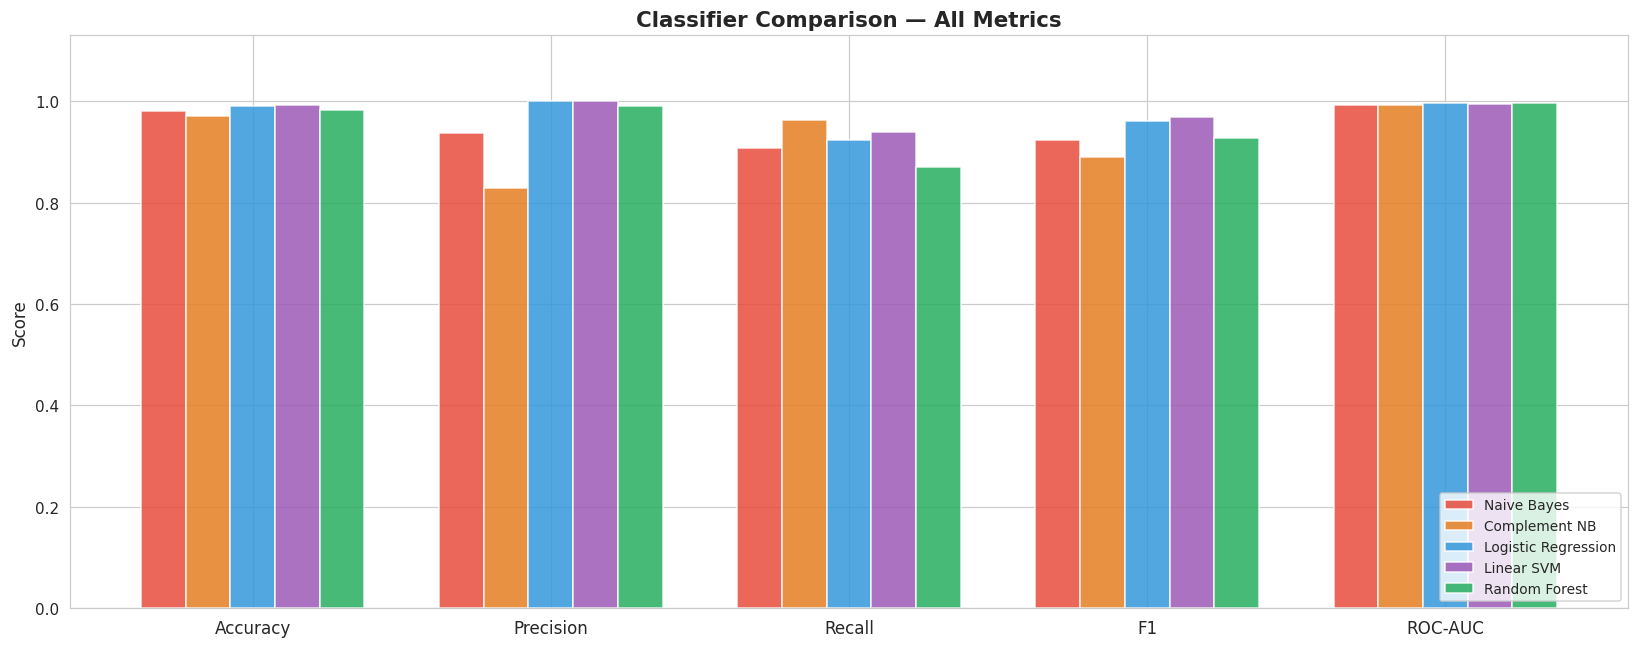

In [ ]:
# Grouped bar chart
metrics     = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
mlabels     = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
model_names = list(results.keys())
palette     = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#27ae60']

x = np.arange(len(metrics))
w = 0.15

fig, ax = plt.subplots(figsize=(15, 6))

for i, (name, color) in enumerate(zip(model_names, palette)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * w, vals, w, label=name,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + w * 2)
ax.set_xticklabels(mlabels, fontsize=11)
ax.set_ylim(0, 1.13)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Classifier Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

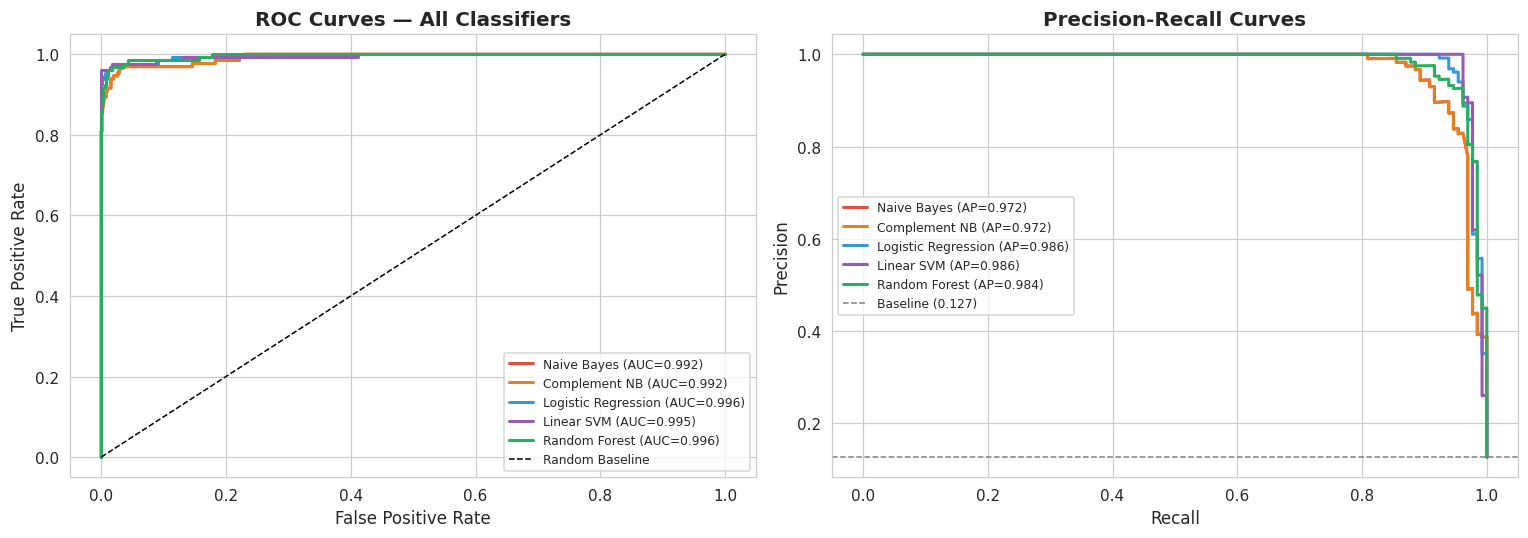

In [ ]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, color in zip(model_names, palette):
    fpr, tpr, _ = roc_curve(y_test, results[name]['proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC={results[name]['roc_auc']:.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random Baseline')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — All Classifiers', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')

# Precision-Recall curves
for name, color in zip(model_names, palette):
    prec_c, rec_c, _ = precision_recall_curve(y_test, results[name]['proba'])
    ap = average_precision_score(y_test, results[name]['proba'])
    axes[1].plot(rec_c, prec_c, lw=2, color=color,
                 label=f"{name} (AP={ap:.3f})")

axes[1].axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
                label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
best_name = max(results, key=lambda n: results[n]['f1'])
best      = results[best_name]

print(f"Best model: {best_name}")
print(f"F1 Score  : {best['f1']:.4f}")
print(f"ROC-AUC   : {best['roc_auc']:.4f}")
print()
print(classification_report(
    y_test, best['preds'],
    target_names=['Ham (Legit)', 'Spam']
))

Best model: Linear SVM
F1 Score  : 0.9685
ROC-AUC   : 0.9950

              precision    recall  f1-score   support

 Ham (Legit)       0.99      1.00      1.00       903
        Spam       1.00      0.94      0.97       131

    accuracy                           0.99      1034
   macro avg       1.00      0.97      0.98      1034
weighted avg       0.99      0.99      0.99      1034



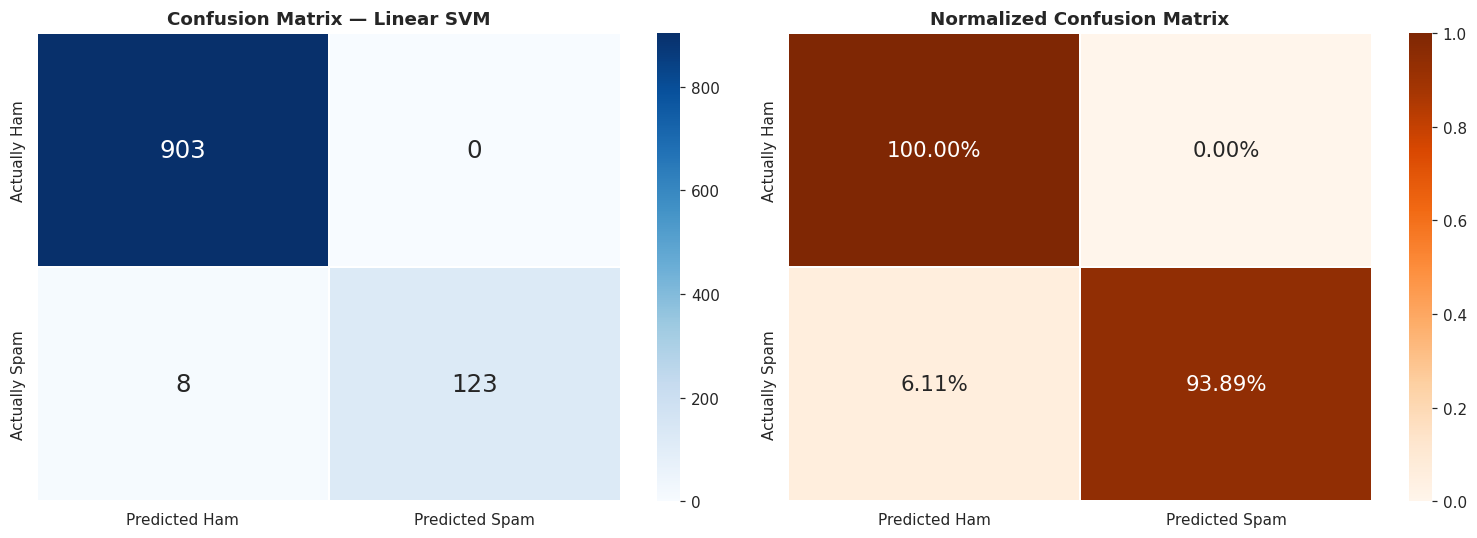

Spam caught correctly     : 123  out of 131  (93.9%)
Legit flagged as spam     : 0  (false alarms)
Spam missed (slipped thru): 8  (missed spam)


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, best['preds'])
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actually Ham', 'Actually Spam'],
            linewidths=1, annot_kws={'size': 16}, ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_name}',
                   fontsize=12, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actually Ham', 'Actually Spam'],
            linewidths=1, annot_kws={'size': 14}, ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Spam caught correctly     : {tp:,}  out of {tp+fn:,}  ({tp/(tp+fn)*100:.1f}%)")
print(f"Legit flagged as spam     : {fp:,}  (false alarms)")
print(f"Spam missed (slipped thru): {fn:,}  (missed spam)")

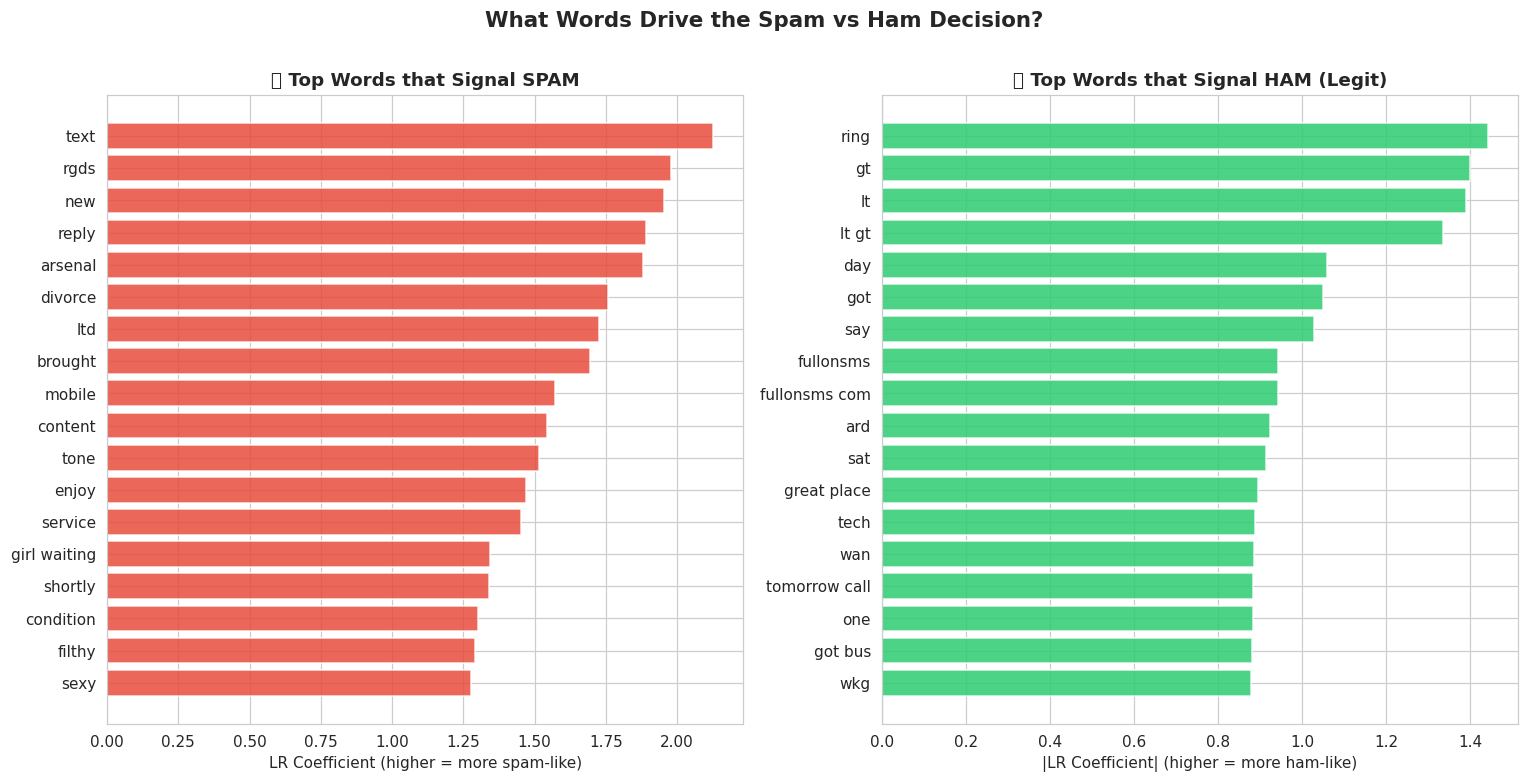

In [ ]:
# What words push the model toward spam vs ham?
# Works best with Logistic Regression
lr_model = results['Logistic Regression']['model']
feature_names = np.array(tfidf_word.get_feature_names_out())
coefs = lr_model.coef_[0][:len(feature_names)]  # word TF-IDF coefficients only

n = 18
top_spam_idx = np.argsort(coefs)[-n:][::-1]
top_ham_idx  = np.argsort(coefs)[:n]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Top spam words
axes[0].barh(range(n), coefs[top_spam_idx][::-1],
             color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(n))
axes[0].set_yticklabels(feature_names[top_spam_idx][::-1], fontsize=10)
axes[0].set_title('🚫 Top Words that Signal SPAM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('LR Coefficient (higher = more spam-like)')

# Top ham words
axes[1].barh(range(n), np.abs(coefs[top_ham_idx])[::-1],
             color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(n))
axes[1].set_yticklabels(feature_names[top_ham_idx][::-1], fontsize=10)
axes[1].set_title('✅ Top Words that Signal HAM (Legit)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('|LR Coefficient| (higher = more ham-like)')

plt.suptitle('What Words Drive the Spam vs Ham Decision?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Build an ensemble using the three probability-supporting models
ensemble = VotingClassifier(
    estimators=[
        ('nb',  ComplementNB(alpha=0.1)),
        ('lr',  LogisticRegression(C=5.0, max_iter=1000, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ],
    voting='soft'   # uses predicted probabilities
)

print("Training ensemble (soft voting)...")

# Ensemble needs non-negative data for NB — use word TF-IDF
ensemble.fit(X_train_word, y_train)
ens_preds = ensemble.predict(X_test_word)
ens_proba = ensemble.predict_proba(X_test_word)[:, 1]

ens_f1  = f1_score(y_test, ens_preds)
ens_auc = roc_auc_score(y_test, ens_proba)
ens_acc = accuracy_score(y_test, ens_preds)

print(f"Ensemble — Accuracy: {ens_acc:.4f}  |  F1: {ens_f1:.4f}  |  ROC-AUC: {ens_auc:.4f}")
print()
print(classification_report(y_test, ens_preds, target_names=['Ham', 'Spam']))

Training ensemble (soft voting)...
Ensemble — Accuracy: 0.9874  |  F1: 0.9482  |  ROC-AUC: 0.9961

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       0.99      0.91      0.95       131

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034



Running 5-fold cross-validation on: Linear SVM
CV F1 scores: [0.9254 0.96   0.9412 0.9608 0.9608]
Mean F1     : 0.9496
Std         : 0.0143


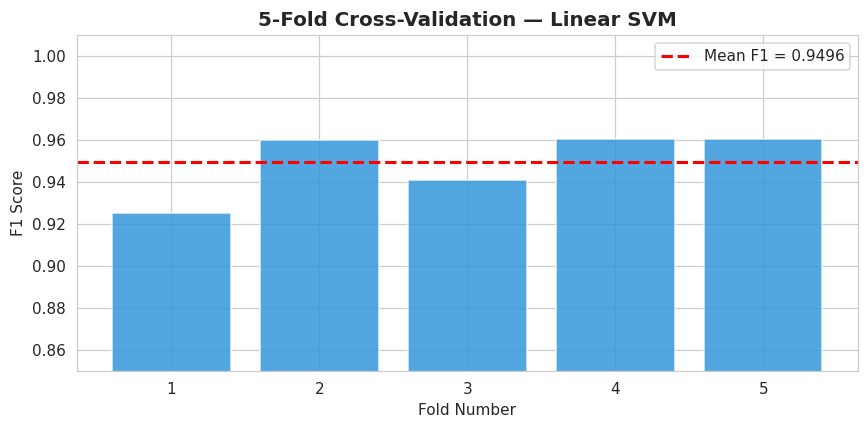

In [ ]:
# 5-fold CV on the best single model to check stability
best_model_obj = best['model']

if best_name in nb_only_models:
    cv_X = X_train_word
else:
    cv_X = X_train_combined

print(f"Running 5-fold cross-validation on: {best_name}")
cv_scores = cross_val_score(
    best_model_obj, cv_X, y_train,
    cv=5, scoring='f1', n_jobs=-1
)

print(f"CV F1 scores: {cv_scores.round(4)}")
print(f"Mean F1     : {cv_scores.mean():.4f}")
print(f"Std         : {cv_scores.std():.4f}")

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='#3498db', edgecolor='white', alpha=0.85)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', lw=2,
            label=f'Mean F1 = {cv_scores.mean():.4f}')
plt.xlabel('Fold Number')
plt.ylabel('F1 Score')
plt.title(f'5-Fold Cross-Validation — {best_name}', fontsize=13, fontweight='bold')
plt.ylim(0.85, 1.01)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(best_model_obj, 'spam_classifier.pkl')
joblib.dump(tfidf_word,     'spam_tfidf_word.pkl')
joblib.dump(tfidf_char,     'spam_tfidf_char.pkl')
joblib.dump(scaler_hc,      'spam_scaler.pkl')

print("Saved files:")
print("  spam_classifier.pkl  — trained classifier")
print("  spam_tfidf_word.pkl  — word TF-IDF vectorizer")
print("  spam_tfidf_char.pkl  — character TF-IDF vectorizer")
print("  spam_scaler.pkl      — hand-crafted feature scaler")

Saved files:
  spam_classifier.pkl  — trained classifier
  spam_tfidf_word.pkl  — word TF-IDF vectorizer
  spam_tfidf_char.pkl  — character TF-IDF vectorizer
  spam_scaler.pkl      — hand-crafted feature scaler


In [ ]:
def get_hand_crafted(text):
    """Extract hand-crafted features from raw text."""
    return [[
        len(text),
        len(text.split()),
        sum(c.isdigit() for c in text),
        sum(c.isupper() for c in text),
        sum(c in string.punctuation for c in text),
        int(bool(re.search(r'http|www|bit\.ly', text, re.IGNORECASE))),
        int(bool(re.search(r'\b\d{10,}\b', text))),
        int(bool(re.search(r'\bfree\b|\bwon\b|\bwinner\b|\bclaim\b|\bprize\b',
                           text, re.IGNORECASE))),
    ]]


def predict_spam(raw_message, threshold=0.5):
    """
    Takes a raw SMS message string.
    Returns: verdict ('SPAM' or 'HAM') and confidence score.
    """
    cleaned = preprocess(raw_message)

    # Vectorize
    vec_word = tfidf_word.transform([cleaned])
    vec_char = tfidf_char.transform([cleaned])
    hc_feats = scaler_hc.transform(get_hand_crafted(raw_message))
    combined = hstack([vec_word, vec_char, csr_matrix(hc_feats)])

    # Predict
    if best_name in nb_only_models:
        prob = best_model_obj.predict_proba(vec_word)[0][1]
    elif best_name == 'Linear SVM':
        dec = best_model_obj.decision_function(combined)[0]
        prob = 1 / (1 + np.exp(-dec))  # sigmoid to get probability-like score
    else:
        prob = best_model_obj.predict_proba(combined)[0][1]

    verdict = '🚫 SPAM' if prob >= threshold else '✅ HAM (Legit)'
    bar_len  = int(prob * 30)
    bar      = '█' * bar_len + '░' * (30 - bar_len)

    print(f"  Message   : {raw_message[:80]}{'...' if len(raw_message)>80 else ''}")
    print(f"  Spam prob : [{bar}] {prob*100:.1f}%")
    print(f"  Verdict   : {verdict}")
    return verdict, prob


# ---- Test messages ----
test_messages = [
    "CONGRATULATIONS! You've been selected as a WINNER! Call now to claim your FREE prize worth £1000!",
    "Hey, are we still meeting at 6pm today? Let me know if you're running late.",
    "URGENT: Your account has been compromised. Click this link immediately: http://secure-verify.ru",
    "Can you pick up some milk on your way home? We're out.",
    "FREE Ringtones! Txt MUSIC to 87066 now! 3 tones 4 FREE! Offer ends midnight!",
    "Happy birthday! Hope you have an amazing day 🎂",
    "You have won a £500 gift card. Call 0800-WINNER to claim. Limited time offer!",
    "The meeting is rescheduled to Thursday 3pm. Please confirm your attendance.",
]

print(f"Using model: {best_name}\n")
print("=" * 65)

for msg in test_messages:
    predict_spam(msg)
    print("-" * 65)

Using model: Linear SVM

  Message   : CONGRATULATIONS! You've been selected as a WINNER! Call now to claim your FREE p...
  Spam prob : [███████████████████░░░░░░░░░░░] 63.8%
  Verdict   : 🚫 SPAM
-----------------------------------------------------------------
  Message   : Hey, are we still meeting at 6pm today? Let me know if you're running late.
  Spam prob : [███████░░░░░░░░░░░░░░░░░░░░░░░] 23.9%
  Verdict   : ✅ HAM (Legit)
-----------------------------------------------------------------
  Message   : URGENT: Your account has been compromised. Click this link immediately: http://s...
  Spam prob : [██████████████████░░░░░░░░░░░░] 62.0%
  Verdict   : 🚫 SPAM
-----------------------------------------------------------------
  Message   : Can you pick up some milk on your way home? We're out.
  Spam prob : [████░░░░░░░░░░░░░░░░░░░░░░░░░░] 16.0%
  Verdict   : ✅ HAM (Legit)
-----------------------------------------------------------------
  Message   : FREE Ringtones! Txt MUSIC to 870

In [ ]:
# Interactive — try your own message!
my_message = "Congratulations! You've won a free iPhone. Reply YES to claim now!"

print("Your custom message:")
print("="*65)
predict_spam(my_message)

Your custom message:
  Message   : Congratulations! You've won a free iPhone. Reply YES to claim now!
  Spam prob : [██████████████░░░░░░░░░░░░░░░░] 47.8%
  Verdict   : ✅ HAM (Legit)


('✅ HAM (Legit)', np.float64(0.47804437211780776))

In [ ]:
# Show some real errors the model made — always good to understand mistakes
test_df_copy = pd.DataFrame({
    'message'   : X_test_text.values,
    'actual'    : y_test.values,
    'predicted' : best['preds'],
    'spam_prob' : best['proba']
})

false_positives = test_df_copy[
    (test_df_copy['actual']==0) & (test_df_copy['predicted']==1)
].head(5)

false_negatives = test_df_copy[
    (test_df_copy['actual']==1) & (test_df_copy['predicted']==0)
].head(5)

print("FALSE POSITIVES — Legit messages wrongly flagged as spam:")
print("-" * 60)
for _, row in false_positives.iterrows():
    print(f"  [{row['spam_prob']*100:.1f}% spam prob] {row['message'][:100]}")

print(f"\nFALSE NEGATIVES — Spam messages the model missed:")
print("-" * 60)
for _, row in false_negatives.iterrows():
    print(f"  [{row['spam_prob']*100:.1f}% spam prob] {row['message'][:100]}")

FALSE POSITIVES — Legit messages wrongly flagged as spam:
------------------------------------------------------------

FALSE NEGATIVES — Spam messages the model missed:
------------------------------------------------------------
  [48.4% spam prob] babe want dont baby im nasty thing filthyguys fancy rude time sexy bitch go slo hard txt xxx slo msg
  [52.5% spam prob] check choose babe video sm shsex netun fgkslpopw fgkslpo
  [43.6% spam prob] simpson movie released july name band died start film green day blue day red day send
  [47.9% spam prob] xmas new year eve ticket now sale club day till pm thurs fri sat night week selling fast
  [41.0% spam prob] latest news police station toilet stolen cop nothing go
